在本节中，将使用iris（鸢尾花）数据集实现一个简单的分类器。
如前一节所介绍的，iris数据集一共有4个特征值：分别是：sepal length（萼片长度）、sepal width（萼片宽度）、petal length（花瓣长度）、petal width （花瓣宽度）。根据这些数据鸢尾花被分为了3个类：Setosa、Versicolour 和 Virginica，样本数量150个，每类50个。在下面的示例中，为了可视化绘图方便，我们只取了4个特征中的2个（petal length、petal width）用于计算。

In [17]:
import numpy as np
import pandas as pd
iris = pd.read_csv(r"..\DataSet\iris_data.csv")
X = iris.filter(["petal_length","petal_width"])
#将X由pandas的dataFrame类型转为了numpy的narray类型。这一步不是必须的。
X = X.values
y = iris.filter(["species"])
print("Class labels: ",np.unique(y))

Class labels:  ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


np.unique(y)函数返回存储在iris数据集中的三个类标签，鸢尾花类名称 Iris-setosa、Iris-versicolor 和 Iris-virginica。尽管许多scikit-learn函数和类方法也适用于字符串格式的类标签，但推荐使用整数标签的方法，以避免技术故障并提高计算性能，同时占用的内存也更小。此外，将类标签编码为整数是大多数机器学习库中的常见约定。最终，我们将类标签y转换为了一个整数数组，只有3个可能的值，0，1和2。

In [18]:
#首先将y转换为类别
y = y['species'].astype('category')
#使用作为y的值
y = y.cat.codes
#列向量转为行，为了后边计算比较方便
y = y.ravel()

和上一节同样，把数据集分成训练集和测试集：

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

我们随机的将数据分为2份，其中30%（45条记录）用作测试数据，70%（105条记录）用作训练数据。train_test_split 函数在拆分之前已经随机的打乱了数据。否则，来自'Iris-setosa'类和'Iris-versicolor'类的所有记录都将出现在训练数集中；而测试数据集将包含来自'Iris-virginica'类的45个示例。通过random_state参数，使用内部伪随机数生成器，在拆分之前对数据集进行乱序。而使用一个固定random_state值可以确保我们的结果是可重现的，也就是说random_state实际上是内部伪随机数生成器的种子。最后，通过 layerify = y 利用了对分层的内置支持。在这种情况下，分层意味着train_test_split方法返回与输入数据集具有相同比例的类标签的训练和测试子集。可以使用NumPy的bincount函数计算数组中每个值的出现次数，以验证是否确实如此：

In [20]:
print(np.bincount(y))
print(np.bincount(y_train))
print(np.bincount(y_test))

[50 50 50]
[35 35 35]
[15 15 15]


和上一节一样，在训练之前还需要对数据进行归一化，统一缩放：

In [21]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

接下来我们使用Skelearn中的感知器进行模型的训练。在训练之前，先了解2个名词：（1）学习率（learn rate）简单说就是学习的速率。一个模型需要对此的训练，通过每次训练的反馈结果来调整参数。粗略的讲，学习率决定了调整的“步伐”大小。学习率是一个超参数，在训练开始值需要指定。学习率过小，会使得收敛的过程变慢，效率不高，同时也有可能陷于局部的极值或鞍点；学习率过大，则有可能越过全局的最优点。（2）Epoch，一个epoch就是使用训练集中的全部样本训练一次。通俗的讲，Epoch的值就是整个训练数据集被反复使用几次。Epoch数是一个超参数，它定义了学习算法在整个训练数据集中的工作次数。一个Epoch意味着训练数据集中的每个样本都有机会更新内部模型参数。同时也可以直观的看到，学习率越小，需要的epoch就越多。
一般而言，简单的感知器是一个二分类的。但是在skeleran中已经做了处理，使其可以进行多分类。下面对感知器进行训练：

In [22]:
from sklearn.linear_model import Perceptron
ppn = Perceptron(eta0=0.1, random_state=5)
ppn.fit(X_train, y_train)

Perceptron(eta0=0.1, random_state=5)

从sklearn.linear_model模块加载Perceptron类后，初始一个新的Perceptron对象并通过fit方法训练模型。在这里，模型参数 eta0 相当于学习率，而n_iter参数定义了epoch的数量（通过训练数据集）。找到合适的学习率需要一些实验。如果学习率太大，算法会超过全局代价最小值。如果学习率太小，算法将需要更多的epoch才能收敛，这会使学习速度变慢——尤其是对于大型数据集。此外，我们使用 random_state参数来确保每个epoch之后训练数据集的初始混洗的可重复性。
在 scikit-learn 中训练了一个模型后，我们可以通过 predict 方法进行预测：

In [23]:
y_pred = ppn.predict(X_test)
#print(y_test.values.ravel())
print('Misclassified examples: %d' % (y_test!= y_pred).sum())


Misclassified examples: 1


In [24]:
from sklearn.metrics import accuracy_score
print('Accuracy: %.3f' % accuracy_score(y_test, y_pred))
print(y_test)

Accuracy: 0.978
[2 0 0 2 1 1 2 1 2 0 0 2 0 1 0 1 2 1 1 2 2 0 1 2 1 1 1 2 0 2 0 0 1 1 2 2 0
 0 0 1 2 2 1 0 0]


最后，我们可以使用7.2节介绍过的Matplot库的函数来绘制新训练的感知器模型的决策区域，并可视化它对不同花卉示例的区分程度。

In [25]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):
    # 设置画图的标记和颜色
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    plt.figure(figsize=(10, 7))
    # 绘制决策面
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution), 
    np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1], alpha=0.8, 
        c=colors[idx], marker=markers[idx], label=cl)
    
    # 高亮测试数据
    if test_idx:
        # plot all examples
        X_test, y_test = X[test_idx, :], y[test_idx]
        
        plt.scatter(X_test[:, 0], X_test[:, 1], c= 'none', edgecolor='black', alpha=1.0, 
        linewidth=1, marker='o', s=100, label='test set')

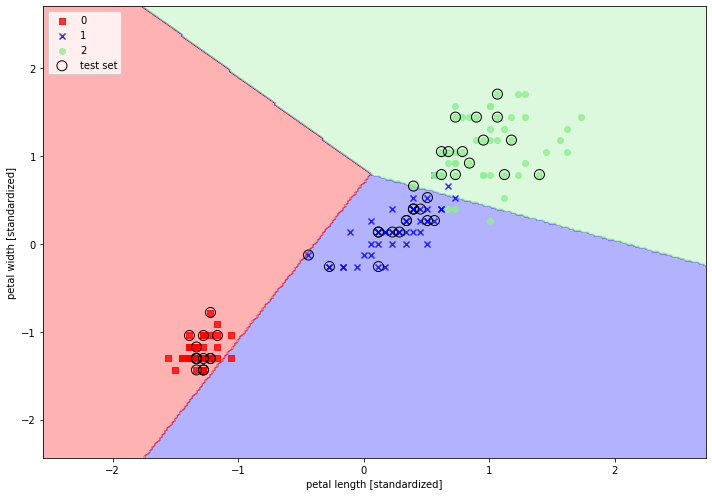

In [26]:
X_combined_std = np.vstack((X_train, X_test))
y_combined = np.hstack((y_train, y_test))
plot_decision_regions(X=X_combined_std, y=y_combined, 
classifier=ppn, test_idx=range(105, 150))
plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

尽管感知器分类机器学习算法效果很好且易于理解，但它最大的缺点是，如果类不是完全线性可分的，它就永远不会收敛。 上一节中的分类任务就存在这样的例子。虽然权重在不断更新，但是每个epoch中总是存在至少一个错误分类的训练示例。 虽然可以改变学习率并增加 epoch 的数量，但是感知器永远不会收敛到这个数据集上。
下面来看看另一种简单但更强大的线性和二元分类问题算法：逻辑回归。 请注意，尽管它的名称是逻辑回归，但它是分类模型，而不是回归模型。逻辑回归是一种分类模型，非常容易实现并且在线性可分的类上表现非常好。 它是工业中使用最广泛的分类算法之一。 与感知器类似，逻辑回归模型也是二元分类的线性模型。逻辑回归可以很容易地推广到多类分类上，称为多项逻辑回归或softmax回归。

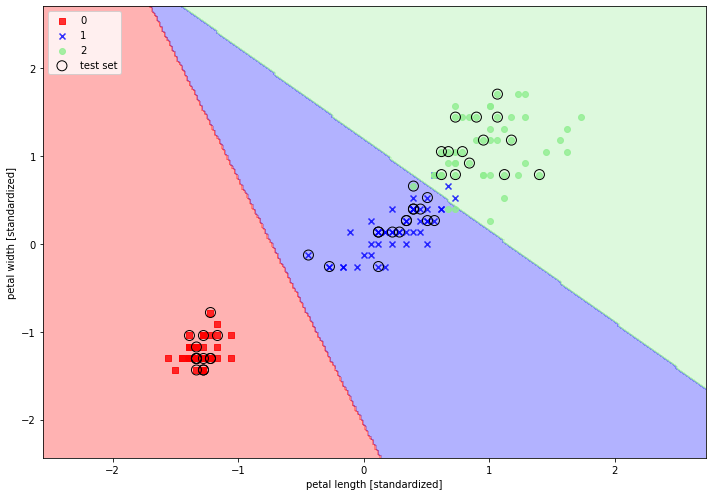

In [27]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(C=100.0, random_state=1, solver='lbfgs', multi_class='ovr')
lr.fit(X_train, y_train)
plot_decision_regions(X_combined_std, y_combined, classifier=lr, test_idx=range(105, 150))
plt.xlabel('花瓣长度')
plt.ylabel('花瓣宽度')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

存在许多不同的优化算法来解决优化问题，这里说的优化方法是指训练模型的参数，使其更快速的收敛的算法。为了最小化逻辑回归损失函数（是一个凸函数），建议使用比常规随机梯度下降 (SGD) 更好的方法。scikit-learn 实现了一整套这样的优化算法，可以通过求解器参数指定，即“newton-cg”、“lbfgs”、“liblinear”、“sag”和“saga”。大多数优化算法应该很容易收敛到全局损失最小值。默认求解器算法“lbfgs”，代表有限内存 Broyden-Fletcher-Goldfarb-Shanno (BFGS) 算法。
可以使用 predict_proba 方法计算训练示例属于某个类别的概率。 例如，可以预测测试数据集中前三条数据的概率如下：

In [29]:
lr.predict_proba(X_test[:3, :])

array([[3.88198890e-09, 1.46859501e-01, 8.53140495e-01],
       [8.34485694e-01, 1.65514306e-01, 3.26990910e-13],
       [8.49251084e-01, 1.50748916e-01, 2.63333387e-14]])

输出数据的第一行表示第1朵花属于3个类别的概率分别大约是0.0%，14.7%和85.3%。很显然，这3个概率值加起来应该等于1。同时85.3%明显占据绝对优势，所以该花朵判定属于第3类。